In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error


In [6]:
df = pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [7]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')


In [12]:
df.columns = df.columns.str.strip()


In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])


In [14]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_sales.head()


,Order Date,Sales
0,2014-01-31,6242.525
1,2014-02-28,1839.658
2,2014-03-31,14573.956
3,2014-04-30,7944.837
4,2014-05-31,6912.787


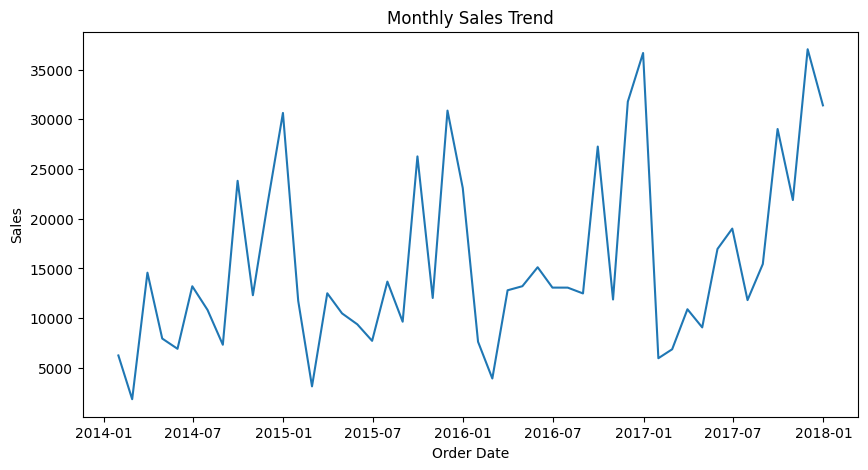

In [16]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()


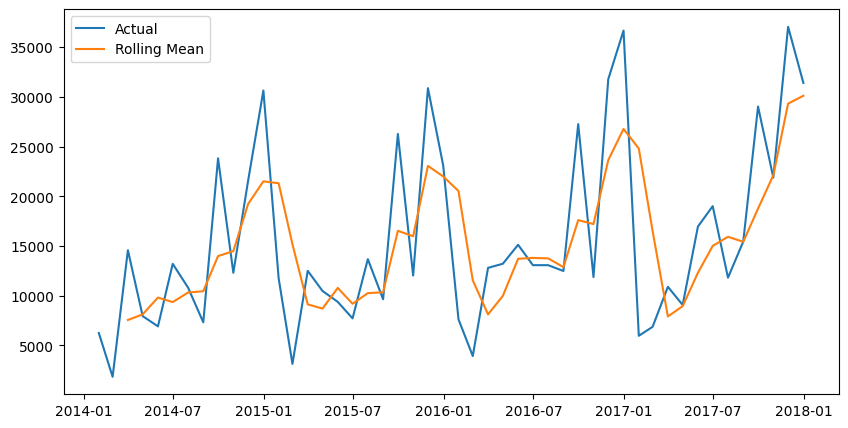

In [18]:
monthly_sales['Rolling_Mean'] = monthly_sales['Sales'].rolling(3).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Actual')
plt.plot(monthly_sales['Order Date'], monthly_sales['Rolling_Mean'], label='Rolling Mean')
plt.legend()
plt.show()


In [19]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]


In [20]:
model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal=None
).fit()

forecast = model.forecast(len(test))


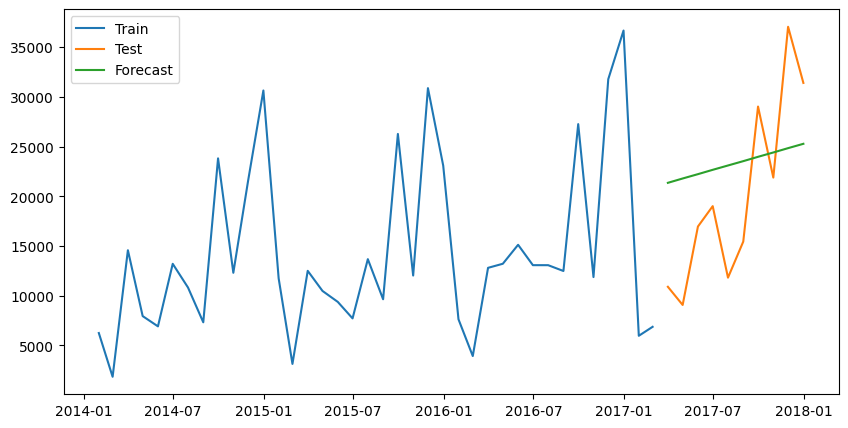

In [22]:
plt.figure(figsize=(10,5))

plt.plot(train['Order Date'], train['Sales'], label='Train')
plt.plot(test['Order Date'], test['Sales'], label='Test')
plt.plot(test['Order Date'], forecast, label='Forecast')

plt.legend()
plt.show()


In [23]:
mae = mean_absolute_error(test['Sales'], forecast)
mape = np.mean(np.abs((test['Sales'] - forecast) / test['Sales'])) * 100

print("MAE:", mae)
print("MAPE:", mape)


MAE: 7741.2363576995995
MAPE: 51.608893486300566


In [26]:
forecast_output = pd.DataFrame({
    'Order Date': test['Order Date'],
    'Actual_Sales': test['Sales'],
    'Forecasted_Sales': forecast
})

forecast_output.to_csv('forecast_output.csv', index=False)
